# FarmTech Solutions - Fase 5
## Entrega 1: Analise Exploratoria, Clusterizacao e Modelos de Regressao

**Aluno:** Richard Schmitz  
**RM:** 567951  
**Curso:** Inteligencia Artificial - FIAP

### Objetivo do notebook
Este notebook apresenta a solucao completa da Entrega 1 da Fase 5. O fluxo foi organizado para seguir o enunciado:

1. carregar e auditar a base `crop_yield.csv`;
2. realizar uma analise exploratoria para entender as culturas e as variaveis climaticas;
3. identificar cenarios discrepantes por meio de analise de outliers;
4. encontrar tendencias de produtividade com clusterizacao nao supervisionada;
5. comparar cinco algoritmos de regressao supervisionada para previsao de rendimento.

### Decisoes metodologicas importantes
- A coluna `Crop` foi mantida na modelagem, porque o tipo de cultura faz parte do problema e carrega grande parte do sinal preditivo.
- O pre-processamento foi colocado dentro de `Pipeline` para evitar vazamento de dados.
- A divisao treino/teste foi feita com `stratify` por cultura para preservar o equilibrio entre as quatro culturas presentes no dataset.
- A analise de outliers foi feita de duas formas: global e por cultura. Isso evita interpretar como anomalia algo que na verdade e uma diferenca estrutural entre culturas.


## 1. Preparacao do ambiente
Nesta etapa importamos as bibliotecas, definimos o estilo visual dos graficos e configuramos a exibicao das tabelas.


In [1]:
# Importacoes principais para manipulacao, visualizacao e machine learning.
import os
import warnings

# Evita avisos de contagem de CPU do joblib em ambientes restritos.
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

# Configuracoes visuais para deixar as tabelas e graficos mais legiveis.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


## 2. Carregamento e visao inicial da base
Aqui verificamos o tamanho da base, os nomes das colunas e a distribuicao das culturas antes de qualquer transformacao.


In [ ]:
# Se estiver no Google Colab, execute esta celula para montar o Google Drive.
# O Colab exibira o botao e o fluxo de autorizacao automaticamente.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive montado com sucesso em /content/drive")
except ModuleNotFoundError:
    print("Google Colab nao detectado. Ignorando a montagem do Google Drive.")


In [2]:
# Leitura do dataset que foi disponibilizado no enunciado.
from pathlib import Path

# Procura o CSV em caminhos comuns do projeto, no ambiente do Colab e no Google Drive.
possible_paths = [
    Path("crop_yield.csv"),
    Path("/content/crop_yield.csv"),
    Path("/content/drive/MyDrive/crop_yield.csv"),
    Path("/content/drive/MyDrive/FarmTech-Solutions-Fase5/crop_yield.csv")
]
csv_path = next((path for path in possible_paths if path.exists()), None)

if csv_path is None:
    try:
        drive_root = Path("/content/drive/MyDrive")
        if drive_root.exists():
            drive_matches = list(drive_root.rglob("crop_yield.csv"))
            if drive_matches:
                csv_path = drive_matches[0]
                print(f"Arquivo encontrado automaticamente no Google Drive: {csv_path}")
    except Exception:
        pass

if csv_path is None:
    try:
        from google.colab import files
        print("Arquivo 'crop_yield.csv' nao encontrado. Selecione o arquivo para upload.")
        uploaded = files.upload()
        uploaded_name = next(iter(uploaded))
        csv_path = Path(uploaded_name)
        print(f"Arquivo carregado: {csv_path}")
    except Exception as exc:
        raise FileNotFoundError(
            "Nao encontrei 'crop_yield.csv'. No Colab, envie o arquivo quando solicitado ou coloque-o na mesma pasta do notebook."
        ) from exc

df = pd.read_csv(csv_path)

# Exibicao inicial da base para checagem rapida.
print(f"Arquivo utilizado: {csv_path}")
print(f"Dimensoes do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Quantidade de culturas distintas: {df['Crop'].nunique()}")
print()
print("Primeiras linhas da base:")
display(df.head())

print("Distribuicao de registros por cultura:")
display(df['Crop'].value_counts().rename_axis('Crop').reset_index(name='Quantidade'))


Dimensoes do dataset: 156 linhas x 6 colunas
Quantidade de culturas distintas: 4

Primeiras linhas da base:
Distribuicao de registros por cultura:


           Crop  Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)  Yield
0  Cocoa, beans                  2,248.92                                 17.72                              83.40                        26.01  11560
1  Cocoa, beans                  1,938.42                                 17.54                              82.11                        26.11  11253
2  Cocoa, beans                  2,301.54                                 17.81                              82.79                        26.24   9456
3  Cocoa, beans                  2,592.35                                 17.61                              85.07                        25.56   9321
4  Cocoa, beans                  2,344.72                                 17.61                              84.12                        25.76   8800

              Crop  Quantidade
0     Cocoa, beans          39
1   Oil palm fruit          39
2      Rice, paddy          39
3  Rubber, natural          39

## 3. Auditoria de qualidade dos dados
O objetivo desta secao e confirmar se a base esta pronta para ser analisada: tipos corretos, valores ausentes, duplicidade e estatisticas descritivas.


In [3]:
# Resumo estrutural da base.
quality_summary = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'valores_ausentes': df.isna().sum(),
    'valores_unicos': df.nunique()
})

print("Resumo de qualidade:")
display(quality_summary)

print(f"Registros duplicados: {df.duplicated().sum()}")
print()
print("Estatisticas descritivas das colunas numericas:")
display(df.describe().T)


Resumo de qualidade:
Registros duplicados: 0

Estatisticas descritivas das colunas numericas:


                                         tipo  valores_ausentes  valores_unicos
Crop                                   object                 0               4
Precipitation (mm day-1)              float64                 0              39
Specific Humidity at 2 Meters (g/kg)  float64                 0              33
Relative Humidity at 2 Meters (%)     float64                 0              38
Temperature at 2 Meters (C)           float64                 0              29
Yield                                   int64                 0             155

                                      count      mean       std      min      25%       50%       75%        max
Precipitation (mm day-1)             156.00  2,486.50    289.46 1,934.62 2,302.99  2,424.55  2,718.08   3,085.79
Specific Humidity at 2 Meters (g/kg) 156.00     18.20      0.29    17.54    18.03     18.27     18.40      18.70
Relative Humidity at 2 Meters (%)    156.00     84.74      1.00    82.11    84.12     84.85     85.51      86.10
Temperature at 2 Meters (C)          156.00     26.18      0.26    25.56    26.02     26.13     26.30      26.81
Yield                                156.00 56,153.10 70,421.96 5,249.00 8,327.75 18,871.00 67,518.75 203,399.00

## 4. Analise exploratoria dos dados
A EDA foi dividida em tres perguntas:

- como a base esta distribuida entre as culturas;
- como o `Yield` varia por cultura;
- como as variaveis climaticas se relacionam entre si e com o rendimento.


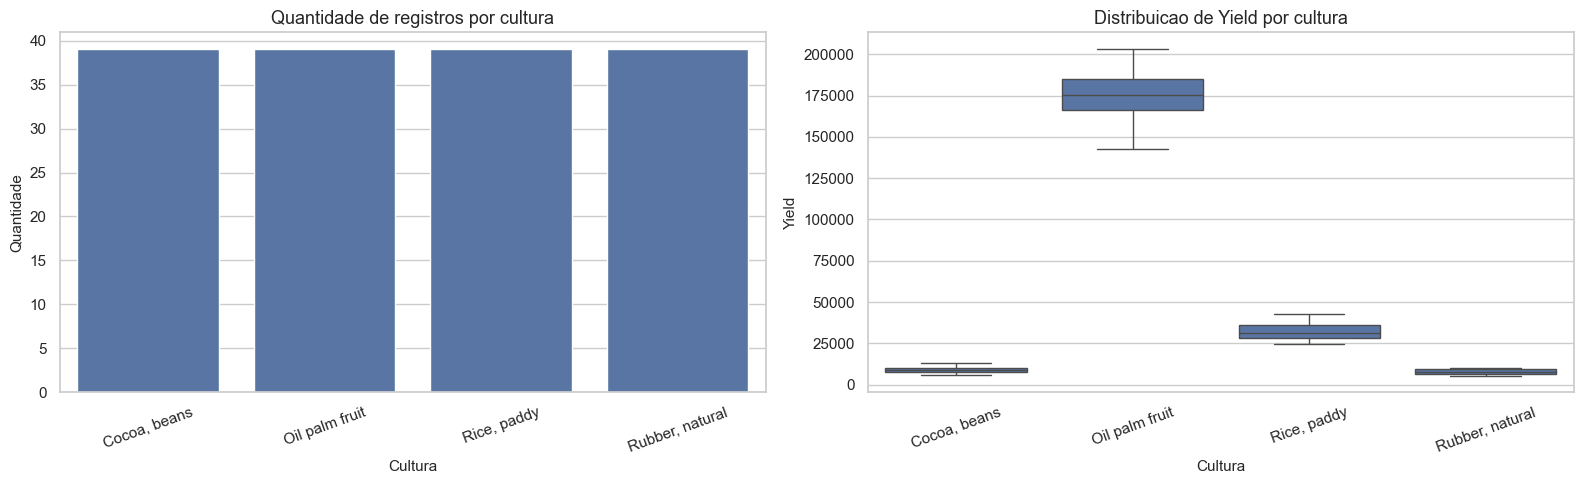

In [4]:
# Figura 1: quantidade de registros por cultura.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

crop_counts = df['Crop'].value_counts().sort_values(ascending=False)
sns.barplot(x=crop_counts.index, y=crop_counts.values, ax=axes[0])
axes[0].set_title('Quantidade de registros por cultura')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=20)

# Figura 2: distribuicao do rendimento por cultura.
sns.boxplot(data=df, x='Crop', y='Yield', ax=axes[1])
axes[1].set_title('Distribuicao de Yield por cultura')
axes[1].set_xlabel('Cultura')
axes[1].set_ylabel('Yield')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


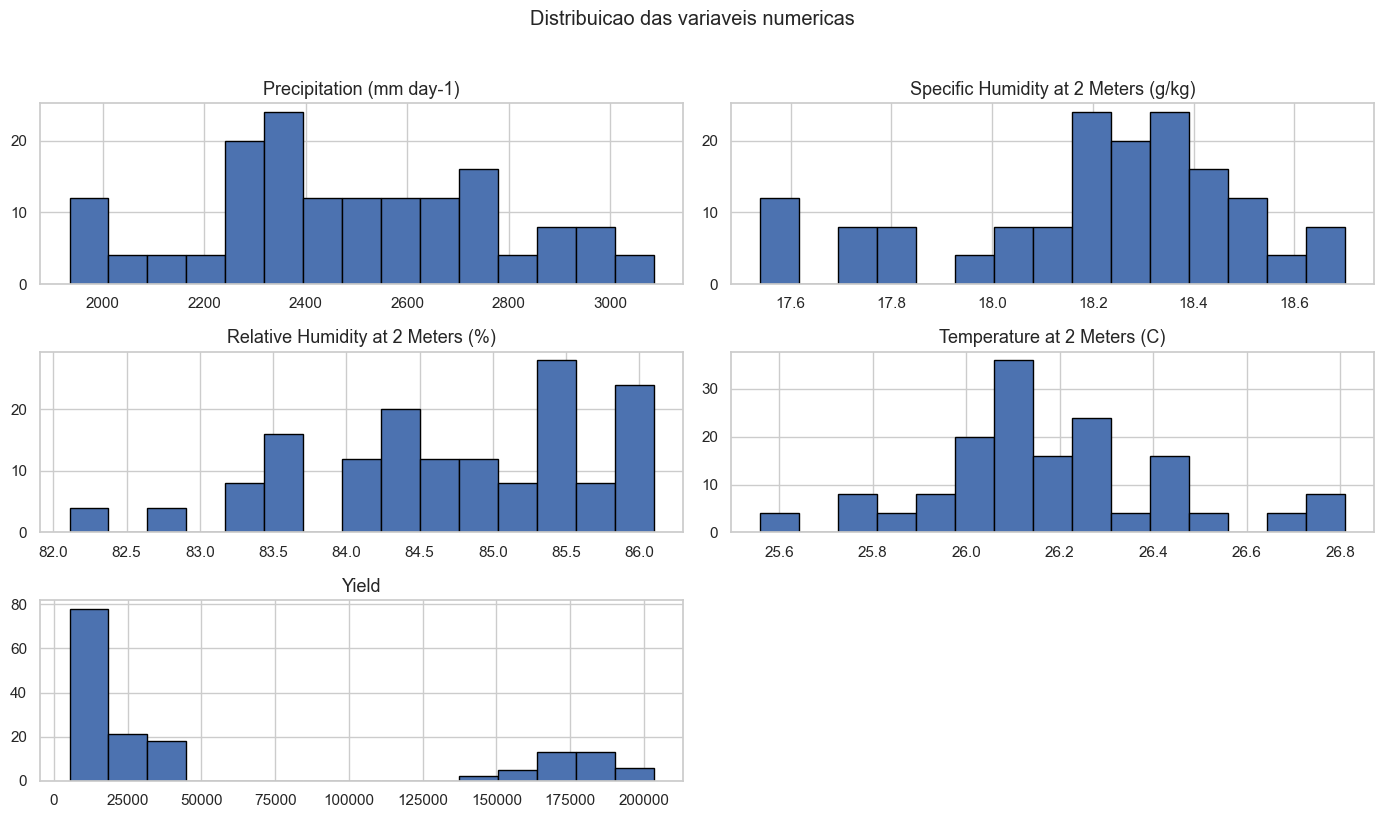

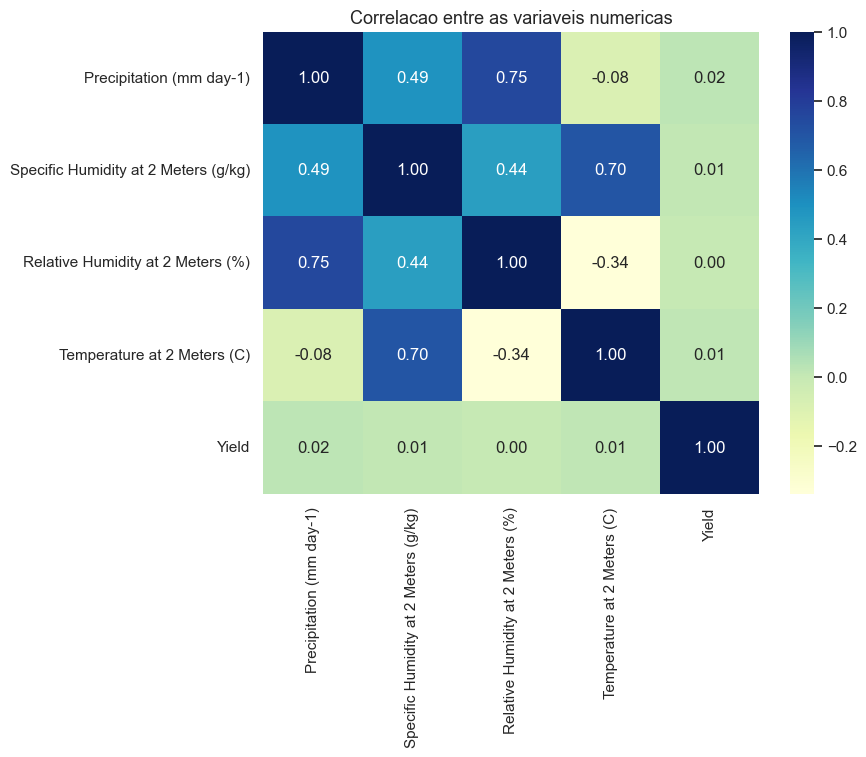

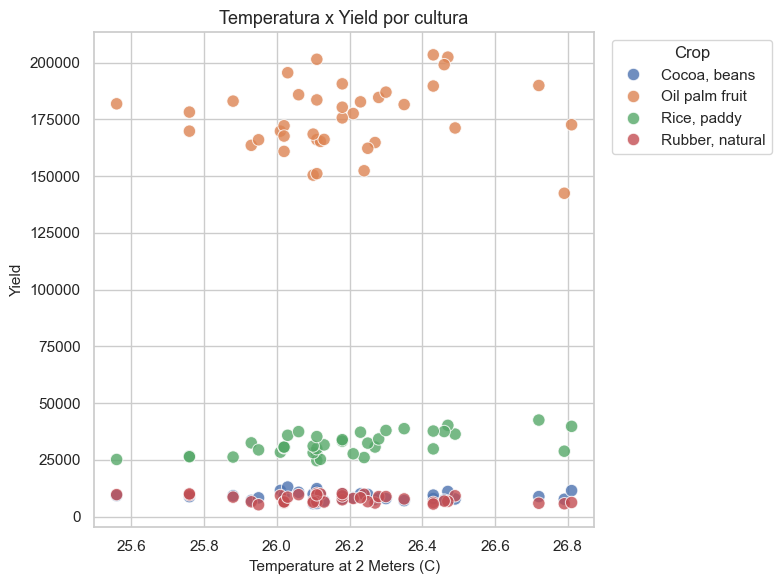

In [5]:
# Seleciona as colunas numericas para as proximas visualizacoes.
numeric_columns = df.select_dtypes(include='number').columns.tolist()

# Histograma das variaveis numericas.
df[numeric_columns].hist(bins=15, figsize=(14, 8), edgecolor='black')
plt.suptitle('Distribuicao das variaveis numericas', y=1.02)
plt.tight_layout()
plt.show()

# Heatmap de correlacao para detectar relacoes lineares.
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlacao entre as variaveis numericas')
plt.show()

# Relacao entre temperatura e rendimento, colorindo por cultura.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Temperature at 2 Meters (C)',
    y='Yield',
    hue='Crop',
    s=80,
    alpha=0.8
)
plt.title('Temperatura x Yield por cultura')
plt.xlabel('Temperature at 2 Meters (C)')
plt.ylabel('Yield')
plt.legend(title='Crop', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Leitura da EDA
Os graficos mostram uma base balanceada entre quatro culturas. O principal insight desta etapa e que o rendimento muda fortemente de uma cultura para outra, enquanto as correlacoes lineares das variaveis climaticas com `Yield` sao fracas quando analisamos toda a base em conjunto. Isso indica que o tipo de cultura nao pode ser ignorado nos modelos supervisionados.


## 5. Outliers e cenarios discrepantes
O enunciado pede identificacao de cenarios discrepantes. Para isso, foi usado o metodo do intervalo interquartil (IQR) em dois niveis:

- **global**: considera a base inteira;
- **por cultura**: calcula limites separados para cada cultura.

Essa comparacao e importante porque um valor alto de `Yield` pode ser normal para uma cultura e parecer anomalo apenas quando misturamos culturas muito diferentes.


Outliers com IQR global:
Outliers com IQR calculado por cultura:


                               Variavel  Outliers globais
0              Precipitation (mm day-1)                 0
1  Specific Humidity at 2 Meters (g/kg)                 0
2     Relative Humidity at 2 Meters (%)                 0
3           Temperature at 2 Meters (C)                12
4                                 Yield                35

              Crop  Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)  Yield
0     Cocoa, beans                         0                                     1                                  1                            4      0
1   Oil palm fruit                         0                                     1                                  1                            4      0
2      Rice, paddy                         0                                     1                                  1                            4      0
3  Rubber, natural                         0                                     1                                  1                            4      0

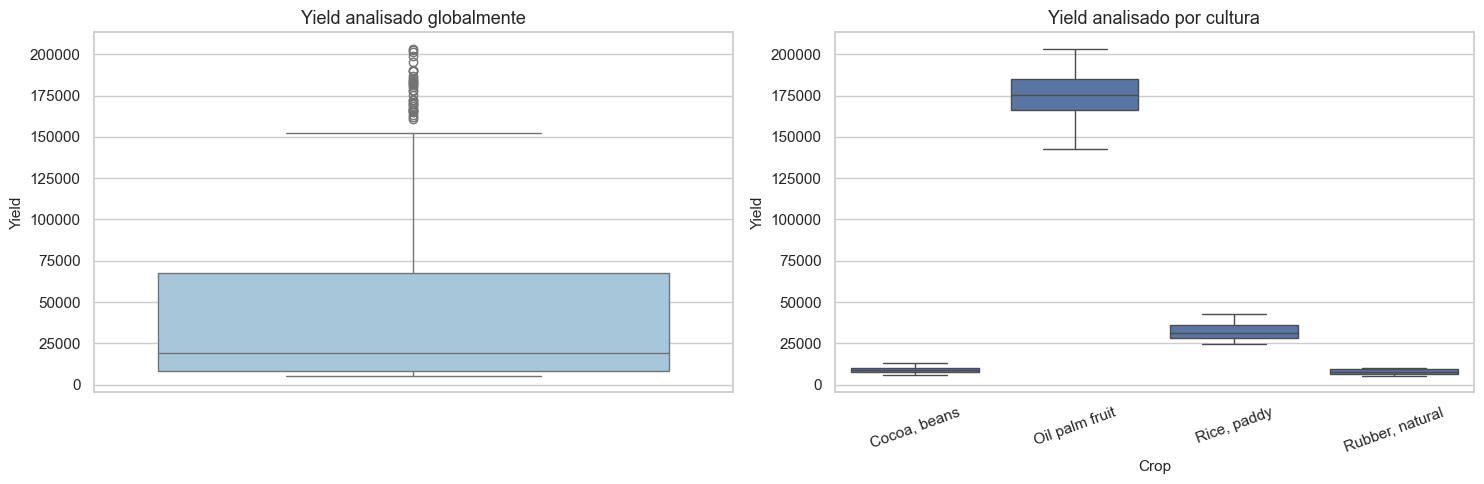

In [6]:
# Funcao auxiliar para contar outliers via IQR.
def iqr_outlier_count(series: pd.Series) -> int:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

# Contagem global de outliers por coluna numerica.
global_outliers = pd.DataFrame({
    'Variavel': numeric_columns,
    'Outliers globais': [iqr_outlier_count(df[col]) for col in numeric_columns]
})

# Contagem de outliers por cultura.
per_crop_rows = []
for crop, group in df.groupby('Crop'):
    row = {'Crop': crop}
    for col in numeric_columns:
        row[col] = iqr_outlier_count(group[col])
    per_crop_rows.append(row)

per_crop_outliers = pd.DataFrame(per_crop_rows)

print('Outliers com IQR global:')
display(global_outliers)
print('Outliers com IQR calculado por cultura:')
display(per_crop_outliers)

# Visualizacao comparativa da distribuicao de Yield.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(y=df['Yield'], ax=axes[0], color='#9ecae1')
axes[0].set_title('Yield analisado globalmente')
axes[0].set_ylabel('Yield')

sns.boxplot(data=df, x='Crop', y='Yield', ax=axes[1])
axes[1].set_title('Yield analisado por cultura')
axes[1].set_xlabel('Crop')
axes[1].set_ylabel('Yield')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### Interpretacao dos outliers
Na analise global, `Yield` aparece com muitos outliers porque as culturas possuem escalas de rendimento muito diferentes. Ja na analise por cultura, `Yield` deixa de ser um problema relevante. Por esse motivo, os modelos supervisionados foram treinados com a base completa, sem remover linhas apenas por conta do rendimento bruto. Essa decisao preserva a representatividade da amostra e evita distorcer o problema real.


## 6. Clusterizacao nao supervisionada
Para explorar tendencias de produtividade, a clusterizacao foi feita com todas as variaveis numericas padronizadas, incluindo `Yield`. Essa escolha e adequada para uma analise exploratoria, porque o objetivo aqui e descobrir perfis de produtividade e nao construir o modelo preditivo.

Foram comparados valores de `k` entre 2 e 6 usando dois criterios:
- **inercia** (metodo do cotovelo);
- **silhouette score** para avaliar a separacao entre grupos.


Perfil medio dos clusters:
Cruzamento entre cluster e cultura:


   k  Inercia  Silhouette
0  2   535.97        0.32
1  3   383.13        0.33
2  4   303.33        0.36
3  5   259.03        0.37
4  6   219.79        0.35

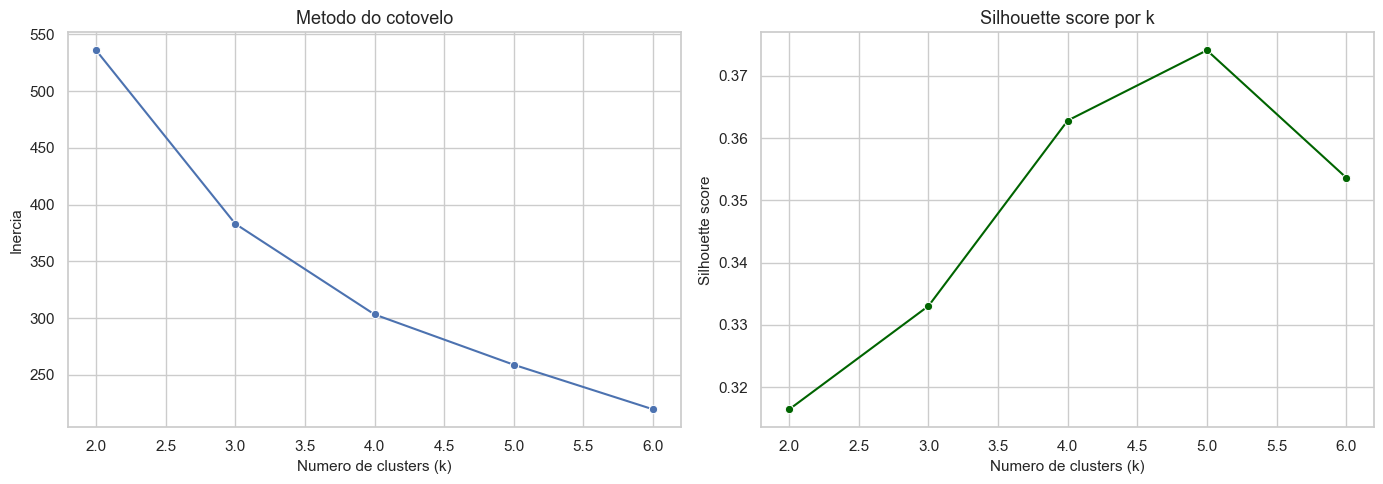

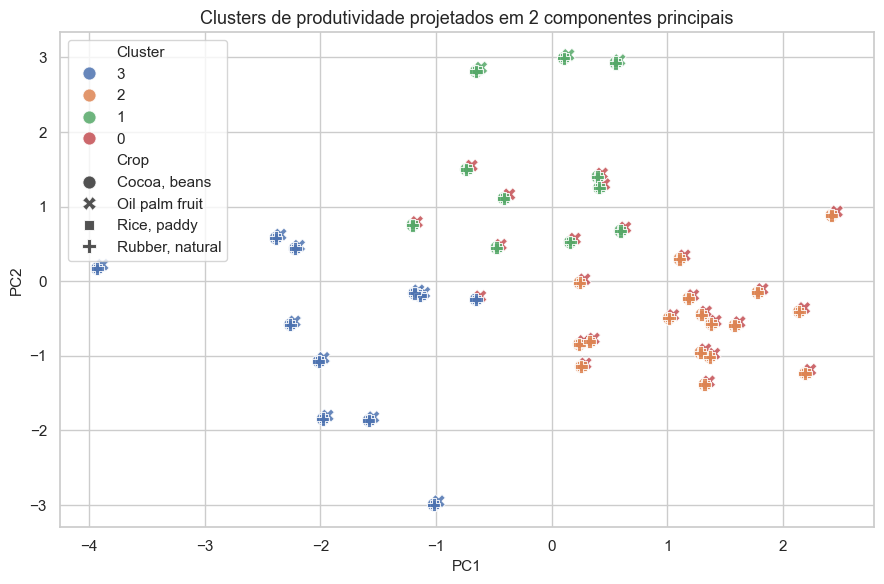

         Quantidade  Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)      Yield
Cluster                                                                                                                                                       
0                26                  2,610.11                                 18.32                              85.20                        26.20 178,310.15
1                36                  2,353.61                                 18.41                              84.11                        26.51  29,671.42
2                51                  2,733.52                                 18.34                              85.65                        26.12  16,624.00
3                43                  2,230.03                                 17.80                              83.90                        25.98  51,344.74

Crop     Cocoa, beans  Oil palm fruit  Rice, paddy  Rubber, natural
Cluster                                                            
0                   0              26            0                0
1                  11               3           11               11
2                  17               0           17               17
3                  11              10           11               11

In [7]:
# Padroniza as variaveis numericas para dar o mesmo peso a todas no K-Means.
cluster_features = numeric_columns.copy()
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df[cluster_features])

# Calcula inercia e silhouette para varios valores de k.
cluster_metrics = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_cluster)
    cluster_metrics.append({
        'k': k,
        'Inercia': model.inertia_,
        'Silhouette': silhouette_score(X_cluster, labels)
    })

cluster_metrics_df = pd.DataFrame(cluster_metrics)
display(cluster_metrics_df)

# Grafico para apoiar a escolha do k.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cluster_metrics_df, x='k', y='Inercia', marker='o', ax=axes[0])
axes[0].set_title('Metodo do cotovelo')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')

sns.lineplot(data=cluster_metrics_df, x='k', y='Silhouette', marker='o', ax=axes[1], color='darkgreen')
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

# Adota k=4 por ser uma solucao interpretavel e com boa separacao para os perfis de produtividade.
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=20)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Reducao para 2 componentes apenas para visualizacao.
pca = PCA(n_components=2, random_state=42)
pca_projection = pca.fit_transform(X_cluster)
plot_df = pd.DataFrame({
    'PC1': pca_projection[:, 0],
    'PC2': pca_projection[:, 1],
    'Cluster': df['Cluster'].astype(str),
    'Crop': df['Crop']
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', style='Crop', s=90, alpha=0.85)
plt.title('Clusters de produtividade projetados em 2 componentes principais')
plt.tight_layout()
plt.show()

# Perfil medio de cada cluster para interpretacao.
cluster_profile = df.groupby('Cluster')[cluster_features].mean().round(2)
cluster_sizes = df['Cluster'].value_counts().sort_index().rename('Quantidade')
cluster_profile.insert(0, 'Quantidade', cluster_sizes)
print('Perfil medio dos clusters:')
display(cluster_profile)

print('Cruzamento entre cluster e cultura:')
display(pd.crosstab(df['Cluster'], df['Crop']))


### Leitura dos clusters
A clusterizacao separou a base em quatro perfis de produtividade. O cruzamento com `Crop` mostra que os grupos nao sao apenas uma copia exata das culturas; eles representam combinacoes de cultura e condicoes climaticas. Esse resultado atende ao objetivo exploratorio do trabalho, ajudando a identificar cenarios com rendimentos mais altos e mais baixos.


## 7. Modelagem supervisionada com cinco algoritmos
Nesta etapa, o alvo e prever `Yield` a partir das variaveis climaticas e do tipo de cultura.

### Boas praticas aplicadas
- divisao treino/teste com `stratify` por cultura;
- transformacoes dentro de `Pipeline`;
- codificacao `OneHotEncoder` para a variavel `Crop`;
- validacao cruzada no conjunto de treino para comparar a estabilidade dos modelos.


In [8]:
# Define colunas de entrada e variavel alvo.
feature_columns = ['Crop'] + [col for col in df.columns if col not in ['Crop', 'Yield', 'Cluster']]
target_column = 'Yield'

X = df[feature_columns]
y = df[target_column]

# Mantem o equilibrio entre culturas no treino e no teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df['Crop']
)

numeric_features = [col for col in feature_columns if col != 'Crop']
categorical_features = ['Crop']

# Pre-processamento para modelos que se beneficiam de escala numerica.
scaled_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

# Pre-processamento para modelos baseados em arvore, que nao precisam de padronizacao.
tree_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

# Cinco algoritmos de regressao para comparacao.
models = {
    'Linear Regression': Pipeline([
        ('preprocess', scaled_preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('preprocess', scaled_preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', tree_preprocessor),
        ('model', RandomForestRegressor(n_estimators=300, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocess', tree_preprocessor),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
    'SVR': Pipeline([
        ('preprocess', scaled_preprocessor),
        ('model', SVR(kernel='rbf', C=100000, epsilon=1000, gamma='scale'))
    ])
}

# Usa validacao cruzada apenas no treino para medir estabilidade.
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained_models = {}

for name, pipeline in models.items():
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        },
        n_jobs=1
    )

    # Ajusta o modelo no treino inteiro e avalia no holdout final.
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    trained_models[name] = pipeline

    results.append({
        'Modelo': name,
        'CV R2 (media)': cv_scores['test_r2'].mean(),
        'CV MAE (media)': -cv_scores['test_mae'].mean(),
        'CV RMSE (media)': -cv_scores['test_rmse'].mean(),
        'Teste R2': r2_score(y_test, predictions),
        'Teste MAE': mean_absolute_error(y_test, predictions),
        'Teste RMSE': mean_squared_error(y_test, predictions) ** 0.5
    })

results_df = pd.DataFrame(results).sort_values('Teste R2', ascending=False).reset_index(drop=True)
display(results_df.round(4))

best_model_name = results_df.loc[0, 'Modelo']
print(f"Melhor modelo no conjunto de teste: {best_model_name}")


Melhor modelo no conjunto de teste: Ridge Regression


              Modelo  CV R2 (media)  CV MAE (media)  CV RMSE (media)  Teste R2  Teste MAE  Teste RMSE
0   Ridge Regression           0.99        5,749.90         8,367.73      0.99   4,953.27    8,109.23
1  Linear Regression           0.99        5,446.53         8,007.33      0.98   4,988.89    8,543.63
2  Gradient Boosting           0.99        4,758.32         7,729.32      0.98   5,130.74    9,555.56
3      Random Forest           0.99        4,633.18         7,834.97      0.98   4,606.05    9,604.37
4                SVR           0.88       12,716.68        21,768.54      0.91   9,760.58   19,764.72

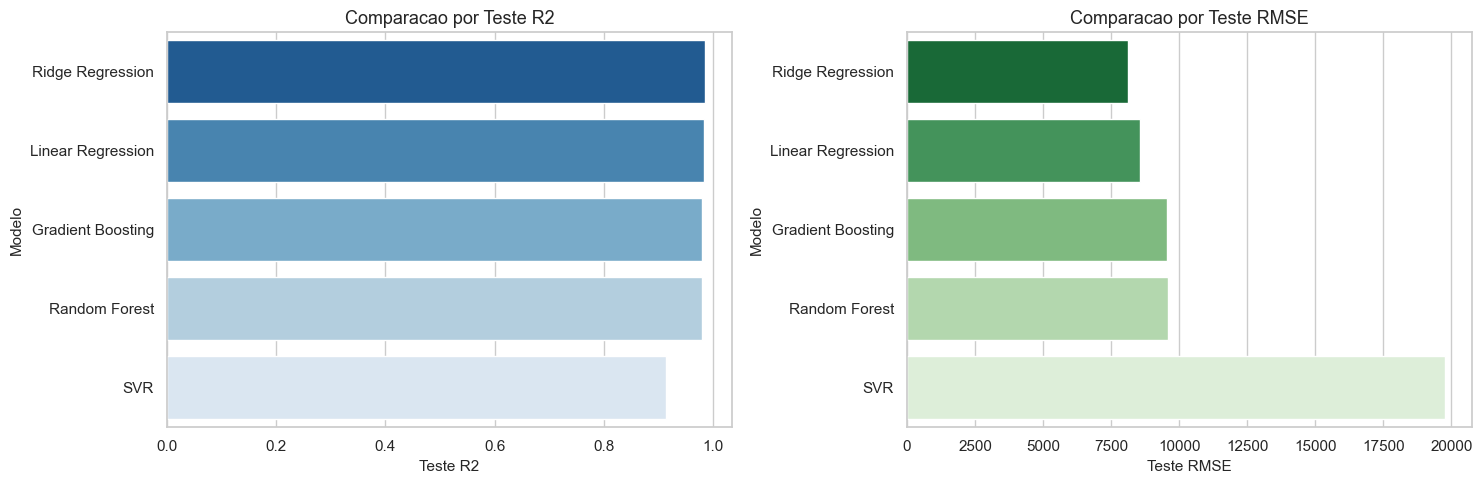

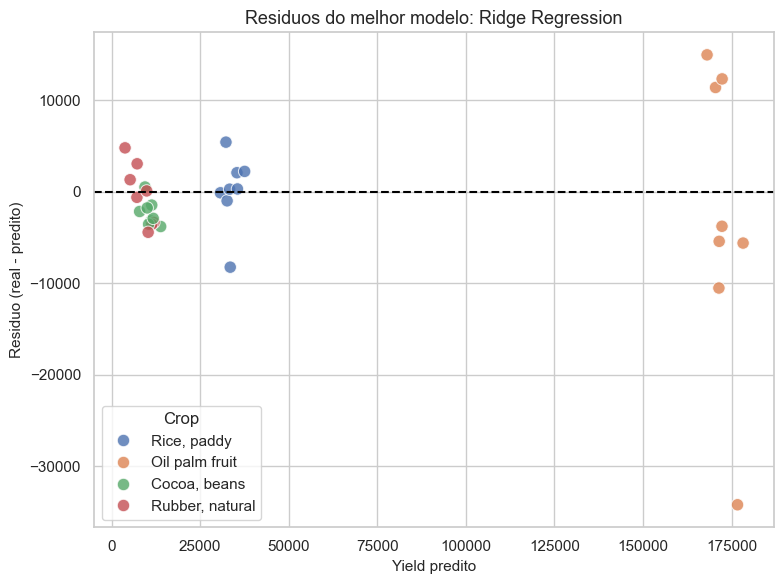

     Real    Predito    Residuo             Crop
0   30614  30,737.56    -123.56      Rice, paddy
1  183004 168,051.51  14,952.49   Oil palm fruit
2   31619  32,621.43  -1,002.43      Rice, paddy
3    9880  11,351.63  -1,471.63     Cocoa, beans
4   10058  13,869.84  -3,811.84     Cocoa, beans
5  160862 171,394.96 -10,532.96   Oil palm fruit
6    6546   7,166.90    -620.90  Rubber, natural
7  168476 172,260.79  -3,784.79   Oil palm fruit
8    7965  11,173.43  -3,208.43     Cocoa, beans
9  181826 170,443.31  11,382.69   Oil palm fruit

In [9]:
# Grafico comparando o desempenho dos cinco modelos no holdout final.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=results_df, x='Teste R2', y='Modelo', ax=axes[0], palette='Blues_r')
axes[0].set_title('Comparacao por Teste R2')
axes[0].set_xlabel('Teste R2')
axes[0].set_ylabel('Modelo')

sns.barplot(data=results_df, x='Teste RMSE', y='Modelo', ax=axes[1], palette='Greens_r')
axes[1].set_title('Comparacao por Teste RMSE')
axes[1].set_xlabel('Teste RMSE')
axes[1].set_ylabel('Modelo')

plt.tight_layout()
plt.show()

# Analisa os residuos do melhor modelo para entender a qualidade das previsoes.
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
residual_df = pd.DataFrame({
    'Real': y_test,
    'Predito': y_pred_best,
    'Residuo': y_test - y_pred_best,
    'Crop': X_test['Crop']
}).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=residual_df, x='Predito', y='Residuo', hue='Crop', s=80, alpha=0.8)
plt.axhline(0, color='black', linestyle='--')
plt.title(f'Residuos do melhor modelo: {best_model_name}')
plt.xlabel('Yield predito')
plt.ylabel('Residuo (real - predito)')
plt.tight_layout()
plt.show()

display(residual_df.head(10))


                                    Variavel  Coeficiente  Impacto absoluto
5                   cat__Crop_Oil palm fruit   120,691.58        120,691.58
7                  cat__Crop_Rubber, natural   -48,774.84         48,774.84
4                     cat__Crop_Cocoa, beans   -47,387.27         47,387.27
6                      cat__Crop_Rice, paddy   -24,529.47         24,529.47
1  num__Specific Humidity at 2 Meters (g/kg)    23,663.60         23,663.60
3           num__Temperature at 2 Meters (C)   -19,798.53         19,798.53
2     num__Relative Humidity at 2 Meters (%)   -19,617.52         19,617.52
0              num__Precipitation (mm day-1)     2,864.14          2,864.14

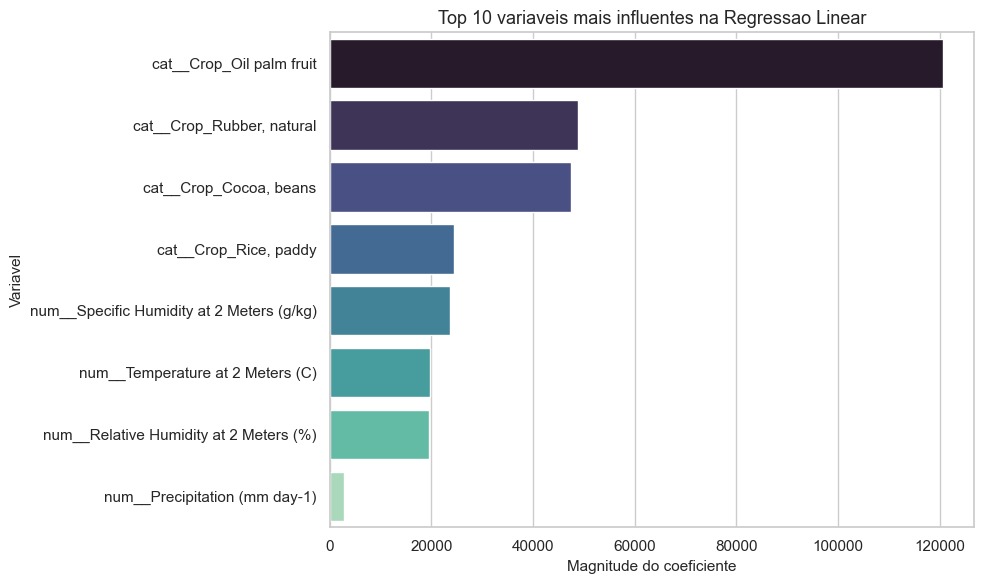

In [10]:
# Interpreta o melhor modelo usando os coeficientes padronizados da regressao linear.
# Mesmo que outro modelo tenha desempenho parecido, a regressao linear facilita a interpretacao.
linear_pipeline = trained_models['Linear Regression']
linear_model = linear_pipeline.named_steps['model']
feature_names = linear_pipeline.named_steps['preprocess'].get_feature_names_out()

coef_df = pd.DataFrame({
    'Variavel': feature_names,
    'Coeficiente': linear_model.coef_,
    'Impacto absoluto': np.abs(linear_model.coef_)
}).sort_values('Impacto absoluto', ascending=False)

display(coef_df.head(10).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Impacto absoluto', y='Variavel', palette='mako')
plt.title('Top 10 variaveis mais influentes na Regressao Linear')
plt.xlabel('Magnitude do coeficiente')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()


## 8. Conclusoes finais
O notebook atende aos quatro pedidos centrais da Entrega 1:

1. **EDA:** a base foi carregada, auditada e visualizada com foco nas culturas e nas variaveis climaticas.
2. **Outliers:** os cenarios discrepantes foram identificados e interpretados com cuidado, evitando remover valores que sao normais dentro de cada cultura.
3. **Clusterizacao:** o K-Means permitiu encontrar perfis distintos de produtividade e contexto climatico.
4. **Regressao supervisionada:** cinco algoritmos foram comparados com metricas adequadas (`R2`, `MAE` e `RMSE`).

### Principais achados
- O tipo de cultura e uma variavel central para explicar o rendimento.
- Sem considerar `Crop`, os modelos ficam subespecificados; com `Crop`, os resultados melhoram de forma consistente.
- Os modelos lineares e ensembles tiveram desempenho muito forte neste dataset, mostrando que a previsao de rendimento e viavel com as variaveis disponiveis.
- O `SVR` tambem foi mantido na comparacao para ampliar a diversidade dos algoritmos testados.

### Limitacoes
- A base e pequena para conclusoes amplas fora deste contexto.
- O dataset nao traz componente temporal nem informacoes de solo em detalhes.
- O valor absoluto de `Yield` varia bastante entre culturas, entao a interpretacao deve sempre considerar o tipo de safra.
